In [91]:
from one.api import ONE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [70]:
one = ONE(
    base_url='https://openalyx.internationalbrainlab.org',
    silent=True
)

In [71]:
def trials_to_df(trials):
    """
    Convert IBL trials object to a pandas DataFrame
    using only 1-D trial-wise fields.
    """
    data = {}
    for k, v in trials.items():
        if hasattr(v, 'ndim') and v.ndim == 1:
            data[k] = v
    return pd.DataFrame(data)

In [72]:
eids = [
    'e2b845a1-e313-4a08-bc61-a5f662ed295e',
    # add more EIDs here
]


In [73]:
results = {}


In [76]:
for eid in eids:
    print(f'\nAnalyzing EID: {eid}')
    eid_result = {}

    # ---- Session metadata ----
    details = one.get_details(eid)
    eid_result['subject'] = details.get('subject')
    eid_result['date'] = details.get('date')
    eid_result['lab'] = details.get('lab')

    # ---- Behavioral data ----
    trials = one.load_object(eid, 'trials', revision='latest')
    trials_df = trials_to_df(trials)

    eid_result['n_trials'] = len(trials_df)

    # Signed contrast
    trials_df['signed_contrast'] = (
        trials_df['contrastRight'].fillna(0)
        - trials_df['contrastLeft'].fillna(0)
    )

    # reaction time definition
    trials_df['reaction_time'] = (
        trials_df['response_times'] - trials_df['goCue_times']
    )

    accuracy = np.mean(trials_df['feedbackType'] == 1)
    median_rt = np.nanmedian(trials_df['reaction_time'])

    eid_result['behavior'] = {
        'accuracy': float(accuracy),
        'median_rt': float(median_rt)
    }

    # ---- Probe insertions ----
    insertions = one.alyx.rest('insertions', 'list', session=eid)
    eid_result['n_probes'] = len(insertions)
    eid_result['pids'] = [ins['id'] for ins in insertions]

    results[eid] = eid_result



Analyzing EID: e2b845a1-e313-4a08-bc61-a5f662ed295e


/usr/local/lib/python3.12/dist-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


In [77]:
results

{'e2b845a1-e313-4a08-bc61-a5f662ed295e': {'subject': 'UCLA036',
  'date': datetime.date(2022, 3, 9),
  'lab': 'churchlandlab_ucla',
  'n_trials': 476,
  'behavior': {'accuracy': 0.7542016806722689, 'median_rt': 0.839041171603867},
  'n_probes': 2,
  'pids': ['80f6ffdd-f692-450f-ab19-cd6d45bfd73e',
   'ac839451-05bc-493e-b167-558b2b195baa']}}

In [78]:
def get_valid_trials(trials_df):
    valid = (
        (trials_df['choice'] != 0) &
        (trials_df['feedbackType'].isin([1, -1])) &
        (trials_df['reaction_time'] > 0) &
        np.isfinite(trials_df['reaction_time'])
    )
    return trials_df[valid].reset_index(drop=True)


In [79]:
trials_df = get_valid_trials(trials_df)


In [80]:
rt_median = np.nanmedian(trials_df['reaction_time'])

trials_df['confidence'] = np.where(
    trials_df['reaction_time'] <= rt_median,
    'high',
    'low'
)


In [86]:
datasets = one.list_datasets(eid, filename='spikes.times.npy')

collections = sorted({
    Path(ds).parent.as_posix()
    for ds in datasets
})

print(collections)

['alf/probe00/pykilosort', 'alf/probe00/pykilosort/#2024-03-22#', 'alf/probe00/pykilosort/#2024-05-06#', 'alf/probe01/pykilosort', 'alf/probe01/pykilosort/#2024-05-06#']


In [87]:
if len(collections) == 0:
    print('No neural data for this EID')
else:
    for collection in collections:
        print(f'Loading {collection}')

        spikes = one.load_object(
            eid,
            'spikes',
            collection=collection,
            revision='latest'
        )

        clusters = one.load_object(
            eid,
            'clusters',
            collection=collection,
            revision='latest'
        )

        print(f'  spikes: {len(spikes["times"])}')
        print(f'  clusters: {len(np.unique(spikes["clusters"]))}')


Loading alf/probe00/pykilosort


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-05-06#/spikes.amps.npy: 100%|██████████| 294M/294M [00:03<00:00, 90.2MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-05-06#/spikes.clusters.npy: 100%|██████████| 147M/147M [00:01<00:00, 79.6MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-05-06#/spikes.depths.npy: 100%|██████████| 294M/294M [00:01<00:00, 157MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-05-06#/spikes.samples.npy: 100%|██████████| 294M/294M [00:02<00:00, 126MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort

  spikes: 36723836
  clusters: 1091
Loading alf/probe00/pykilosort/#2024-03-22#


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-03-22#/spikes.amps.npy: 100%|██████████| 257M/257M [00:05<00:00, 43.3MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-03-22#/spikes.times.npy: 100%|██████████| 257M/257M [00:03<00:00, 82.9MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-03-22#/spikes.samples.npy: 100%|██████████| 257M/257M [00:02<00:00, 92.3MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#2024-03-22#/spikes.depths.npy: 100%|██████████| 257M/257M [00:02<00:00, 113MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe00/pykilosort/#

  spikes: 32076935
  clusters: 1671
Loading alf/probe00/pykilosort/#2024-05-06#
  spikes: 36723836
  clusters: 1091
Loading alf/probe01/pykilosort


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe01/pykilosort/#2024-05-06#/spikes.amps.npy: 100%|██████████| 302M/302M [00:05<00:00, 57.9MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe01/pykilosort/#2024-05-06#/spikes.clusters.npy: 100%|██████████| 151M/151M [00:02<00:00, 64.1MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe01/pykilosort/#2024-05-06#/spikes.depths.npy: 100%|██████████| 302M/302M [00:02<00:00, 147MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe01/pykilosort/#2024-05-06#/spikes.samples.npy: 100%|██████████| 302M/302M [00:02<00:00, 121MB/s] 
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/UCLA036/2022-03-09/001/alf/probe01/pykilosor

  spikes: 37794417
  clusters: 1590
Loading alf/probe01/pykilosort/#2024-05-06#
  spikes: 37794417
  clusters: 1590


In [88]:
# Alignment parameters
t_before = 0.5
t_after = 1.0
bin_size = 0.02  # 20 ms

bins = np.arange(-t_before, t_after + bin_size, bin_size)
bin_centers = (bins[:-1] + bins[1:]) / 2

In [89]:
def build_population_matrix(spikes, trials_df, bins):
    """
    Returns:
    X: (n_trials, n_neurons, n_timebins)
    neuron_ids: array of cluster ids
    """

    spike_times = spikes['times']
    spike_clusters = spikes['clusters']

    neuron_ids = np.unique(spike_clusters)
    n_trials = len(trials_df)
    n_neurons = len(neuron_ids)
    n_bins = len(bins) - 1

    X = np.zeros((n_trials, n_neurons, n_bins), dtype=np.float32)

    align_times = trials_df['stimOn_times'].values

    for ti, t0 in enumerate(align_times):
        t_start = t0 + bins[0]
        t_end = t0 + bins[-1]

        mask = (spike_times >= t_start) & (spike_times < t_end)
        st = spike_times[mask] - t0
        sc = spike_clusters[mask]

        for ni, cid in enumerate(neuron_ids):
            neuron_spikes = st[sc == cid]
            X[ti, ni, :] = np.histogram(neuron_spikes, bins=bins)[0]

    return X, neuron_ids


In [90]:
population_data = {}

for collection in collections:
    print(f'Building population matrix for {collection}')

    spikes = one.load_object(eid, 'spikes', collection=collection, revision='latest')

    X, neuron_ids = build_population_matrix(spikes, trials_df, bins)

    population_data[collection] = {
        'X': X,
        'neurons': neuron_ids
    }

    print('  Shape:', X.shape)


Building population matrix for alf/probe00/pykilosort
  Shape: (469, 1091, 75)
Building population matrix for alf/probe00/pykilosort/#2024-03-22#
  Shape: (469, 1671, 75)
Building population matrix for alf/probe00/pykilosort/#2024-05-06#
  Shape: (469, 1091, 75)
Building population matrix for alf/probe01/pykilosort
  Shape: (469, 1590, 75)
Building population matrix for alf/probe01/pykilosort/#2024-05-06#
  Shape: (469, 1590, 75)


In [92]:
def compute_neural_manifold(X, n_components=6):
    """
    X: (trials, neurons, time)
    Returns:
    Z: (trials, time, components)
    pca: fitted PCA object
    """

    n_trials, n_neurons, n_time = X.shape

    # Flatten trials × time
    X_flat = X.transpose(0, 2, 1).reshape(-1, n_neurons)

    # Z-score neurons
    X_flat = StandardScaler().fit_transform(X_flat)

    pca = PCA(n_components=n_components)
    Z_flat = pca.fit_transform(X_flat)

    # Restore shape
    Z = Z_flat.reshape(n_trials, n_time, n_components)

    return Z, pca


In [93]:
manifolds = {}

for collection, pdata in population_data.items():
    X = pdata['X']

    Z, pca = compute_neural_manifold(X)

    manifolds[collection] = {
        'Z': Z,
        'pca': pca
    }

    print(f'{collection}: explained variance:',
          np.sum(pca.explained_variance_ratio_[:3]))


alf/probe00/pykilosort: explained variance: 0.05080695
alf/probe00/pykilosort/#2024-03-22#: explained variance: 0.039918635
alf/probe00/pykilosort/#2024-05-06#: explained variance: 0.050806947
alf/probe01/pykilosort: explained variance: 0.07875484
alf/probe01/pykilosort/#2024-05-06#: explained variance: 0.07875481


In [94]:
correct = trials_df['feedbackType'] == 1
incorrect = trials_df['feedbackType'] == -1

def mean_trajectory(Z, mask):
    return Z[mask].mean(axis=0)  # (time, components)


In [95]:
for collection, data in manifolds.items():
    Z = data['Z']

    traj_correct = mean_trajectory(Z, correct)
    traj_incorrect = mean_trajectory(Z, incorrect)

    dist = np.linalg.norm(traj_correct - traj_incorrect, axis=1)

    print(f'{collection} mean traj separation:', dist.mean())


alf/probe00/pykilosort mean traj separation: 2.710039
alf/probe00/pykilosort/#2024-03-22# mean traj separation: 2.5190272
alf/probe00/pykilosort/#2024-05-06# mean traj separation: 2.7100117
alf/probe01/pykilosort mean traj separation: 2.199133
alf/probe01/pykilosort/#2024-05-06# mean traj separation: 2.199217


In [96]:
high_ev = np.abs(trials_df['signed_contrast']) >= 0.25
low_ev  = np.abs(trials_df['signed_contrast']) < 0.25


In [97]:
def trajectory_dispersion(Z):
    """
    Z: (trials, time, components)
    Returns:
    dispersion: (time,)
    """
    mean_traj = Z.mean(axis=0)
    dist = np.linalg.norm(Z - mean_traj, axis=2)
    return dist.mean(axis=0)


In [98]:
confidence_results = {}

for collection, data in manifolds.items():
    Z = data['Z']

    conf = {}

    conf['correct'] = trajectory_dispersion(Z[correct])
    conf['incorrect'] = trajectory_dispersion(Z[incorrect])

    conf['high_ev'] = trajectory_dispersion(Z[high_ev])
    conf['low_ev']  = trajectory_dispersion(Z[low_ev])

    confidence_results[collection] = conf


In [99]:
post_stim = bin_centers > 0

def scalar_confidence(dispersion):
    return dispersion[post_stim].mean()


In [100]:
for collection, conf in confidence_results.items():
    print(f'\n{collection}')

    print('  Correct:', scalar_confidence(conf['correct']))
    print('  Incorrect:', scalar_confidence(conf['incorrect']))

    print('  High evidence:', scalar_confidence(conf['high_ev']))
    print('  Low evidence:', scalar_confidence(conf['low_ev']))



alf/probe00/pykilosort
  Correct: 8.041842
  Incorrect: 6.938911
  High evidence: 7.9084144
  Low evidence: 7.612389

alf/probe00/pykilosort/#2024-03-22#
  Correct: 6.9415803
  Incorrect: 5.7534447
  High evidence: 6.907626
  Low evidence: 6.4131813

alf/probe00/pykilosort/#2024-05-06#
  Correct: 8.041631
  Incorrect: 6.9390154
  High evidence: 7.908064
  Low evidence: 7.6124325

alf/probe01/pykilosort
  Correct: 11.575011
  Incorrect: 11.30286
  High evidence: 11.094138
  Low evidence: 11.727203

alf/probe01/pykilosort/#2024-05-06#
  Correct: 11.575035
  Incorrect: 11.302945
  High evidence: 11.094199
  Low evidence: 11.727229


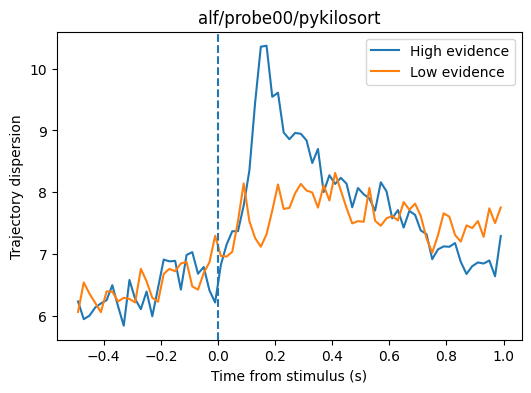

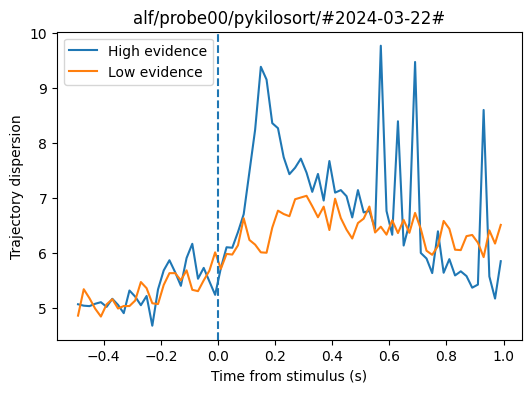

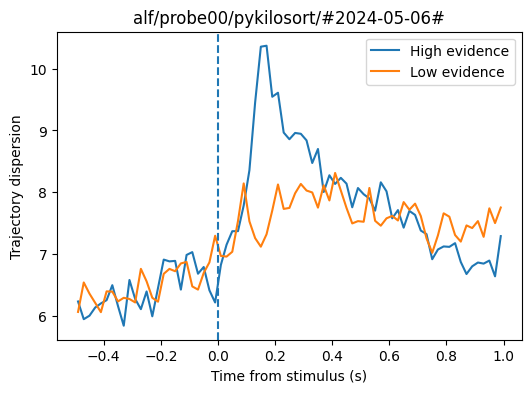

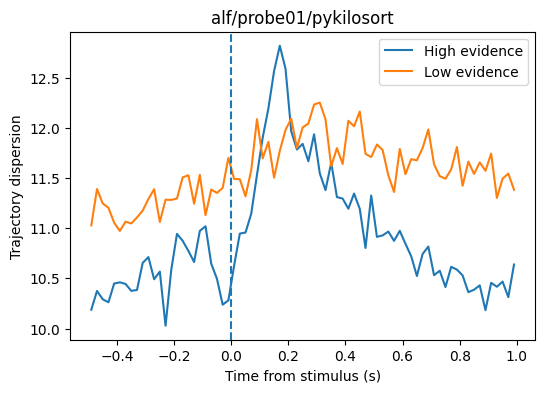

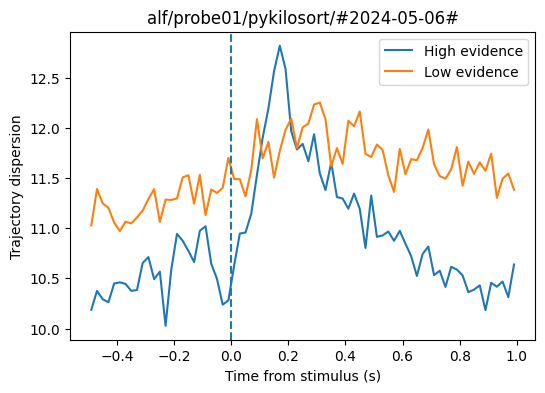

In [101]:


for collection, conf in confidence_results.items():
    plt.figure(figsize=(6,4))

    plt.plot(bin_centers, conf['high_ev'], label='High evidence')
    plt.plot(bin_centers, conf['low_ev'], label='Low evidence')

    plt.axvline(0, linestyle='--')
    plt.xlabel('Time from stimulus (s)')
    plt.ylabel('Trajectory dispersion')
    plt.title(collection)
    plt.legend()
    plt.show()
